# DermaVision - Phase 2: Baseline (MobileNetV2) - Stable Fine-Tuning

**Correction**: Previous fine-tuning crashed accuracy because **BatchNormalization** layers were unfrozen. In Keras applications (like MobileNetV2), BN layers must remain frozen even when fine-tuning, or they will destroy the pre-trained weights.

**Strategy**:
1.  **Stage 1**: Train head (Base Frozen).
2.  **Stage 2**: Unfreeze base, but **KEEP BN LAYERS FROZEN**.

---

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import shutil

# Define Backup Directory
BACKUP_DIR = 'backup/DermaVision'

# Load Data
if os.path.exists('X_train.npy'):
    print("Loading data from local storage...")
elif os.path.exists(os.path.join(BACKUP_DIR, 'X_train.npy')):
    print(f"Loading data from backup ({BACKUP_DIR})...")
    # Copy from backup to current dir for easy access
    for file in ['X_train.npy', 'y_train.npy', 'X_val.npy', 'y_val.npy', 'X_test.npy', 'y_test.npy']:
        shutil.copy(os.path.join(BACKUP_DIR, file), '.')
else:
    print("ERROR: Data not found! Please run 01_DataSetup.ipynb first.")

if os.path.exists('X_train.npy'):
    X_train = np.load('X_train.npy')
    y_train = np.load('y_train.npy')
    X_val = np.load('X_val.npy')
    y_val = np.load('y_val.npy')
    X_test = np.load('X_test.npy')
    y_test = np.load('y_test.npy')

Loading data from local storage...


In [2]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input, Rescaling, RandomFlip, RandomRotation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def create_model():
    inputs = Input(shape=(128, 128, 3))
    
    # Augmentation
    x = RandomFlip("horizontal_and_vertical")(inputs)
    x = RandomRotation(0.2)(x)
    x = Rescaling(scale=2.0, offset=-1.0)(x)
    
    base_model = MobileNetV2(
        input_tensor=x,
        include_top=False,
        weights='imagenet'
    )
    
    # Start Frozen
    base_model.trainable = False
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(4, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return base_model, model

## Stage 1: Warmup (Frozen Base)

In [3]:
if 'X_train' in locals():
    base_model, model = create_model()

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("STAGE 1: Warming up head (15 epochs)...")
    history_warmup = model.fit(
        X_train, y_train,
        epochs=15,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=1
    )

C:\Users\asus\AppData\Local\Temp\ipykernel_23736\4166600580.py:15: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
STAGE 1: Warming up head (15 epochs)...
Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.6500 - loss: 0.8447 - val_accuracy: 0.7033 - val_loss: 0.6549
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.7179 - loss: 0.6434 - val_accuracy: 0.7383 - val_loss: 0.6423
Epoch 3/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.7311 - loss: 0.5983 - val_accuracy: 0.7283 - val_loss: 0.6017
Epoch 4/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.7379 - loss: 0.5802 - val_accuracy: 0.7383 - val_loss: 0.5882
Epoch 5/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.7468 - loss: 0.5690 - val_accuracy: 0.7333 - val_loss: 0.5914
Epoch 6/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.7550 - loss: 0.5444 - val_accuracy: 0.7433 - val_loss: 0.5920
Epoch 7/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.7607 - loss: 0.5446 - val_accuracy: 0.7333 - val_loss: 0.6253
Epoch 8/15
88/88 ━━━━

## Stage 2: Correct Fine-Tuning

We unfreeze the base, but forcefully keep BatchNormalization layers frozen.

In [4]:
if 'history_warmup' in locals():
    # Unfreeze base
    base_model.trainable = True

    # CRITICAL: Freeze BatchNormalization layers
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    # Recompile with lower LR
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        EarlyStopping(patience=10, restore_best_weights=True, monitor='val_accuracy', verbose=1),
        ReduceLROnPlateau(factor=0.2, patience=3, min_lr=1e-7, monitor='val_loss', verbose=1)
    ]

    print("STAGE 2: Fine-Tuning (BatchNormalization Frozen)...")
    history_finetune = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1
    )

STAGE 2: Fine-Tuning (BatchNormalization Frozen)...
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 161ms/step - accuracy: 0.7875 - loss: 0.4645 - val_accuracy: 0.7483 - val_loss: 0.5643 - learning_rate: 1.0000e-05
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.7961 - loss: 0.4552 - val_accuracy: 0.7617 - val_loss: 0.5461 - learning_rate: 1.0000e-05
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.8175 - loss: 0.4139 - val_accuracy: 0.7517 - val_loss: 0.5581 - learning_rate: 1.0000e-05
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.8139 - loss: 0.4260 - val_accuracy: 0.7483 - val_loss: 0.5719 - learning_rate: 1.0000e-05
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.8293 - loss: 0.3952 - val_accuracy: 0.7667 - val_loss: 0.5234 - learning_rate: 1.0000e-05
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.8346 - loss: 0.3924 - val_accuracy: 0.7733 - val_loss: 0.5594 - learning_rate: 1.0000e-05
Epoch 

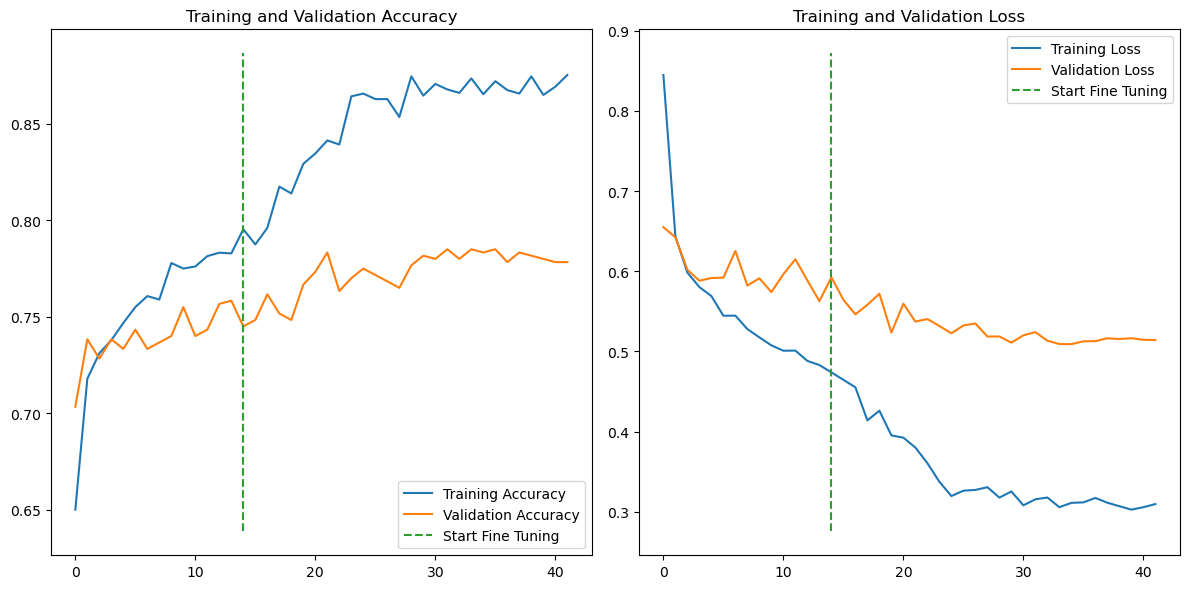

In [5]:
# Plot Full Training History (Stage 1 + Stage 2)
if 'history_finetune' in locals():
    acc = history_warmup.history['accuracy'] + history_finetune.history['accuracy']
    val_acc = history_warmup.history['val_accuracy'] + history_finetune.history['val_accuracy']
    loss = history_warmup.history['loss'] + history_finetune.history['loss']
    val_loss = history_warmup.history['val_loss'] + history_finetune.history['val_loss']

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.plot([len(history_warmup.history['accuracy'])-1, len(history_warmup.history['accuracy'])-1], 
             plt.ylim(), label='Start Fine Tuning', linestyle='--')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.plot([len(history_warmup.history['loss'])-1, len(history_warmup.history['loss'])-1], 
             plt.ylim(), label='Start Fine Tuning', linestyle='--')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.tight_layout()
    plt.savefig('baseline_training_history.png', dpi=100)
    plt.show()

In [7]:
if 'model' in locals():
    loss, acc = model.evaluate(X_test, y_test)
    print(f"\nFinal Test Accuracy: {acc*100:.2f}%")

    model.save('baseline_model.keras')
    
    # Backup results
    os.makedirs(BACKUP_DIR, exist_ok=True)
    shutil.copy('baseline_model.keras', BACKUP_DIR)
    shutil.copy('baseline_training_history.png', BACKUP_DIR)
    
    with open('baseline_results.txt', 'w') as f:
        f.write(f"Test Accuracy: {acc*100:.2f}%")
    shutil.copy('baseline_results.txt', BACKUP_DIR)
    
    print(f"Results backed up to {BACKUP_DIR}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8017 - loss: 0.4972

Final Test Accuracy: 80.17%
Results backed up to backup/DermaVision
